In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_PS = pd.read_csv("../data/dataset_PS.csv")
df_PS = df_PS.rename(columns={'file_path': 'path','Affective disorder': 'label'})

print(df_PS.columns)
print(df_PS['label'].value_counts())

Index(['REC_ID', 'path', 'label'], dtype='object')
label
1    70
0    70
Name: count, dtype: int64


In [3]:
class EEGImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'path']
        label = self.df.loc[idx, 'label']
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [4]:
transform = transforms.Compose([
    transforms.Resize((128, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [5]:
train_df_PS, temp_df_PS = train_test_split(df_PS, test_size=0.4, stratify=df_PS['label'], random_state=42)
val_df_PS, test_df_PS = train_test_split(temp_df_PS, test_size=0.5, stratify=temp_df_PS['label'], random_state=42)

print("Train:\n", train_df_PS['label'].value_counts())
print("Val:\n", val_df_PS['label'].value_counts())
print("Test:\n", test_df_PS['label'].value_counts())

Train:
 label
0    42
1    42
Name: count, dtype: int64
Val:
 label
0    14
1    14
Name: count, dtype: int64
Test:
 label
0    14
1    14
Name: count, dtype: int64


In [6]:
train_dataset_PS = EEGImageDataset(train_df_PS, transform)
val_dataset_PS   = EEGImageDataset(val_df_PS, transform)
test_dataset_PS  = EEGImageDataset(test_df_PS, transform)

train_loader_PS = DataLoader(train_dataset_PS, batch_size=16, shuffle=True)
val_loader_PS   = DataLoader(val_dataset_PS, batch_size=16, shuffle=False)
test_loader_PS  = DataLoader(test_dataset_PS, batch_size=16, shuffle=False)

In [7]:
x, y = next(iter(train_loader_PS))
print(x.shape)   # treba biti [batch size, 3, 128, 128]
print(y[:5])

torch.Size([16, 1, 128, 256])
tensor([0, 1, 1, 0, 1])


In [8]:
class SimpleEEGCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [10]:
model = SimpleEEGCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [11]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [12]:
def eval_epoch(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = outputs.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

Epoch 01 | loss=0.6953 | val_acc=0.500
Epoch 02 | loss=0.6902 | val_acc=0.500
Epoch 03 | loss=0.6919 | val_acc=0.500
Epoch 04 | loss=0.7055 | val_acc=0.536
Epoch 05 | loss=0.6955 | val_acc=0.500
Epoch 06 | loss=0.6951 | val_acc=0.500
Epoch 07 | loss=0.6923 | val_acc=0.500
Epoch 08 | loss=0.6952 | val_acc=0.500
Epoch 09 | loss=0.6950 | val_acc=0.500
Epoch 10 | loss=0.6948 | val_acc=0.500
Epoch 11 | loss=0.6942 | val_acc=0.500
Epoch 12 | loss=0.6925 | val_acc=0.500
Epoch 13 | loss=0.6934 | val_acc=0.500
Epoch 14 | loss=0.6870 | val_acc=0.500
Epoch 15 | loss=0.6902 | val_acc=0.500
Epoch 16 | loss=0.6948 | val_acc=0.607
Epoch 17 | loss=0.6892 | val_acc=0.607
Epoch 18 | loss=0.6885 | val_acc=0.607
Epoch 19 | loss=0.7100 | val_acc=0.500
Epoch 20 | loss=0.6857 | val_acc=0.536
Epoch 21 | loss=0.6830 | val_acc=0.643
Epoch 22 | loss=0.6722 | val_acc=0.607
Epoch 23 | loss=0.6445 | val_acc=0.500
Epoch 24 | loss=0.6784 | val_acc=0.536
Epoch 25 | loss=0.6393 | val_acc=0.607
Epoch 26 | loss=0.6196 | 

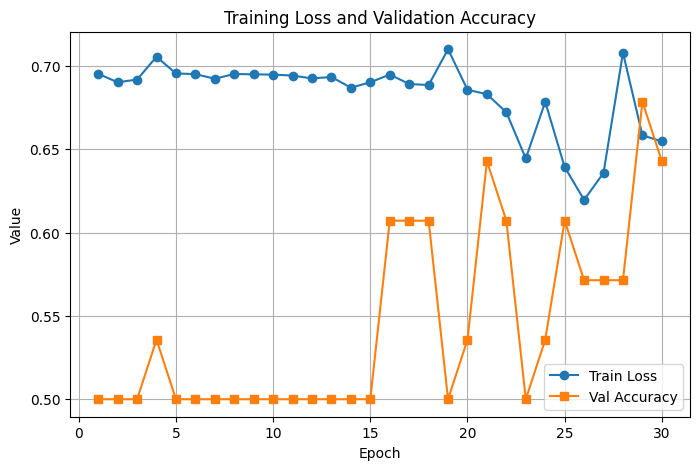

In [13]:
num_epochs = 30

train_losses_PS = []
val_accuracies_PS = []

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader_PS)
    val_acc = eval_epoch(model, val_loader_PS)

    train_losses_PS.append(train_loss)
    val_accuracies_PS.append(val_acc)

    print(f"Epoch {epoch+1:02d} | loss={train_loss:.4f} | val_acc={val_acc:.3f}")

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses_PS, marker='o', label='Train Loss')
plt.plot(epochs, val_accuracies_PS, marker='s', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
model.eval()
y_true_PS = []
y_pred_PS = []

with torch.no_grad():
    for x, y in test_loader_PS:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1).cpu().numpy()

        y_pred_PS.extend(preds)
        y_true_PS.extend(y.numpy())

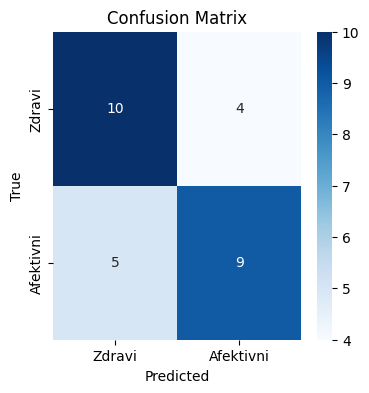

              precision    recall  f1-score   support

      Zdravi       0.67      0.71      0.69        14
   Afektivni       0.69      0.64      0.67        14

    accuracy                           0.68        28
   macro avg       0.68      0.68      0.68        28
weighted avg       0.68      0.68      0.68        28


Accuracy iznosi = 0.6786
F1-score iznosi = 0.6667


In [15]:
cm = confusion_matrix(y_true_PS, y_pred_PS)

plt.figure(figsize=(4,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Zdravi', 'Afektivni'],
    yticklabels=['Zdravi', 'Afektivni']
)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(
    classification_report(
        y_true_PS,
        y_pred_PS,
        target_names=['Zdravi', 'Afektivni']
    )
)

TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
TP = cm[1,1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-10)
recall = TP / (TP + FN + 1e-10)
f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

print(f"\nAccuracy iznosi = {accuracy:.4f}")
print(f"F1-score iznosi = {f1:.4f}")